In [12]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import re
from spc import SPC3
from qua_tools_nv2.dataset import DatasetReader


In [13]:
spad_dir = r'C:\Users\SPUD1\Documents\experiment_workspace\SPAD data'
qm_dir = r'C:\Users\SPUD1\Documents\experiment_workspace\qua-libs\Quantum-Control-Applications\Optically addressable spin qubits\NV2_array_SPAD'

spad_file_header = 'contacq_ODMR_ensemble3'
spad_background = 'background_ensemble3'
qm_file    = r'C:\Users\SPUD1\Documents\experiment_workspace\qua-libs\Quantum-Control-Applications\Optically addressable spin qubits\NV2_array_SPAD\Data\2026-03-13\#85_cw_odmr_145443'

In [14]:
# Toggle whether to use LO frequency (absolute MW freq) or just IF
USE_LO_FREQUENCY = False  # Set False to work in IF space

reader = DatasetReader(qm_dir)

ds_folder = reader.resolve_dataset(qm_file).folder
ds = reader.resolve_dataset(ds_folder)
data = reader.load(ds)

if_hz = np.asarray(data['IF_frequencies'], dtype=float)

cfg = data.get('config') or {}
if USE_LO_FREQUENCY:
    lo_hz = float(cfg['elements']['NV']['mixInputs']['lo_frequency'])
    f_mw_hz = lo_hz + if_hz
else:
    lo_hz = None
    f_mw_hz = if_hz

n_avg = int(data.get('n_avg', 1))
# 'iteration' is 0-indexed:
# Falls back to n_avg when the field is absent
n_iteration = int(data.get('iteration', n_avg - 1)) + 1

print(f'Loaded: {ds.folder}')
print(f"n_avg        : {n_avg}  (requested)")
print(f"n_iteration  : {n_iteration}  (actually completed)")
if n_iteration != n_avg:
    print(f"  ↳ experiment was interrupted at {n_iteration / n_avg * 100:.1f}% of target")
print(f"len(if_hz)   : {len(if_hz)}")
print(f"if_hz range  : {if_hz.min()/1e6:.1f} – {if_hz.max()/1e6:.1f} MHz")
print(f"Expected total frames: {2 * n_iteration * len(if_hz)}") #sig,ref frames per iteration, per frequency point


Loaded: C:\Users\SPUD1\Documents\experiment_workspace\qua-libs\Quantum-Control-Applications\Optically addressable spin qubits\NV2_array_SPAD\Data\2026-03-13\#85_cw_odmr_145443
n_avg        : 1000000  (requested)
n_iteration  : 504293  (actually completed)
  ↳ experiment was interrupted at 50.4% of target
len(if_hz)   : 60
if_hz range  : 65.0 – 94.5 MHz
Expected total frames: 60515160


In [15]:

spad_dir_path = Path(spad_dir)

# -----------------------------------------------------------------
# Discover all part-files matching <header>.spc3, <header>2.spc3, ...
# Only digits (never other text) may follow the header — this prevents
# "ODMR_test_new.spc3" being picked up when header is "ODMR_test".
# -----------------------------------------------------------------
def _spc3_sort_key(p):
    m = re.search(r'(\d+)\.spc3$', p.name, re.IGNORECASE)
    return int(m.group(1)) if m else 0

_part_re = re.compile(
    r'^' + re.escape(spad_file_header) + r'\d*\.spc3$',
    re.IGNORECASE
)

spc3_files = sorted(
    (p for p in spad_dir_path.glob(f'{spad_file_header}*.spc3') if _part_re.match(p.name)),
    key=_spc3_sort_key
)

if not spc3_files:
    raise FileNotFoundError(
        f"No SPC3 files found matching '{spad_file_header}[<digits>].spc3' in\n  {spad_dir_path}"
    )

print(f"Found {len(spc3_files)} SPC3 file(s):")
for fp in spc3_files:
    print(f"  {fp.name}")


Found 58 SPC3 file(s):
  contacq_ODMR_ensemble3.spc3
  contacq_ODMR_ensemble32.spc3
  contacq_ODMR_ensemble33.spc3
  contacq_ODMR_ensemble34.spc3
  contacq_ODMR_ensemble35.spc3
  contacq_ODMR_ensemble36.spc3
  contacq_ODMR_ensemble37.spc3
  contacq_ODMR_ensemble38.spc3
  contacq_ODMR_ensemble39.spc3
  contacq_ODMR_ensemble310.spc3
  contacq_ODMR_ensemble311.spc3
  contacq_ODMR_ensemble312.spc3
  contacq_ODMR_ensemble313.spc3
  contacq_ODMR_ensemble314.spc3
  contacq_ODMR_ensemble315.spc3
  contacq_ODMR_ensemble316.spc3
  contacq_ODMR_ensemble317.spc3
  contacq_ODMR_ensemble318.spc3
  contacq_ODMR_ensemble319.spc3
  contacq_ODMR_ensemble320.spc3
  contacq_ODMR_ensemble321.spc3
  contacq_ODMR_ensemble322.spc3
  contacq_ODMR_ensemble323.spc3
  contacq_ODMR_ensemble324.spc3
  contacq_ODMR_ensemble325.spc3
  contacq_ODMR_ensemble326.spc3
  contacq_ODMR_ensemble327.spc3
  contacq_ODMR_ensemble328.spc3
  contacq_ODMR_ensemble329.spc3
  contacq_ODMR_ensemble330.spc3
  contacq_ODMR_ensemble331.

In [16]:
# extract metadata from first file
frames, header = SPC3.ReadSPC3DataFile(spc3_files[0])

# frames shape: (n_counters, n_frames, n_cols, n_rows)
print("=== Header (first file) ===")
#print(f"  camera_id    : {header.camera_id}")
#print(f"  serial       : {header.SN}")
#print(f"  firmware ver : {header.FW_VER}")
print(f"  n_frames     : {header.N_frames}")
print(f"  n_counters   : {header.N_counters}")
print(f"  n_rows       : {header.N_rows}")
print(f"  n_cols       : {header.N_cols}")
print(f"  bits/pixel   : {header.bit_x_pix}")
print(f"  n_pixels     : {header.N_pix}")
print(f"  HW integ time: {header.HwIntTime * 1e6:.3f} µs")
print(f"  summed frames: {header.SummedFrames}")
print(f"  coarse gate C1: {header.CoarseGate_C1_ON}  ")
integration_time_s= header.CoarseGate_C1_stopPos  - header.CoarseGate_C1_startPos 
print(f"integration time = {integration_time_s * 1e9:.3f} ns")


print(f"\n=== Frames (first file) ===")
print(f"  shape : {frames.shape}  (n_counters, n_frames, n_cols, n_rows)")
print(f"  dtype : {frames.dtype}")
print(f"  min/max (counter 0): {frames[0].min()}, {frames[0].max()}")




=== Header (first file) ===
  n_frames     : 1048574
  n_counters   : 1
  n_rows       : 32
  n_cols       : 32
  bits/pixel   : 8
  n_pixels     : 1024
  HW integ time: 20.800 µs
  summed frames: 1
  coarse gate C1: True  
integration time = 500.000 ns

=== Frames (first file) ===
  shape : (1, 1048574, 32, 32)  (n_counters, n_frames, n_cols, n_rows)
  dtype : uint8
  min/max (counter 0): 0, 4


=== Header (background file) ===
  n_frames     : 50
  n_counters   : 1
  n_rows       : 32
  n_cols       : 32
  bits/pixel   : 16
  n_pixels     : 1024
  HW integ time: 52.000 µs
  summed frames: 2000
  coarse gate C1: False  (0 – 0 ns)

=== Frames (background file) ===
  shape : (1, 50, 32, 32)  (n_counters, n_frames, n_cols, n_rows)
  dtype : uint16
  min/max (counter 0): 1, 6434


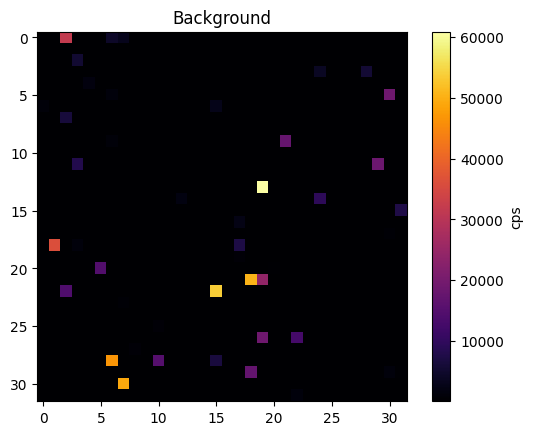

In [17]:
# extract metadata from background file
frames_bg, header_bg = SPC3.ReadSPC3DataFile(str(spad_dir_path / f'{spad_background}.spc3'))

# frames shape: (n_counters, n_frames, n_cols, n_rows)
print("=== Header (background file) ===")
#print(f"  camera_id    : {header.camera_id}")
#print(f"  serial       : {header.SN}")
#print(f"  firmware ver : {header.FW_VER}")
print(f"  n_frames     : {header_bg.N_frames}")
print(f"  n_counters   : {header_bg.N_counters}")
print(f"  n_rows       : {header_bg.N_rows}")
print(f"  n_cols       : {header_bg.N_cols}")
print(f"  bits/pixel   : {header_bg.bit_x_pix}")
print(f"  n_pixels     : {header_bg.N_pix}")
print(f"  HW integ time: {header_bg.HwIntTime * 1e6:.3f} µs")
print(f"  summed frames: {header_bg.SummedFrames}")
print(f"  coarse gate C1: {header_bg.CoarseGate_C1_ON}  "
      f"({header_bg.CoarseGate_C1_startPos * 1e9:.0f} – {header_bg.CoarseGate_C1_stopPos * 1e9:.0f} ns)")

print(f"\n=== Frames (background file) ===")
print(f"  shape : {frames_bg.shape}  (n_counters, n_frames, n_cols, n_rows)")
print(f"  dtype : {frames_bg.dtype}")
print(f"  min/max (counter 0): {frames_bg[0].min()}, {frames_bg[0].max()}")

frames_bg = frames_bg[0].astype(np.float64)  # (n_frames, n_cols, n_rows)
bg_avg = frames_bg.mean(axis=0)  # (rows, cols)
bg_avg_cps = bg_avg / (header_bg.HwIntTime  * header_bg.SummedFrames)  # counts per second per pixel

plt.imshow(bg_avg_cps, cmap='inferno')
plt.colorbar(label='cps')
plt.title('Background')
plt.show()

In [18]:
#load all data files

F              = len(f_mw_hz)
frames_per_rep = 2 * F

header          = None
sig_sum         = None   # (F, rows, cols) float64
ref_sum         = None   # (F, rows, cols) float64
n_complete_reps = 0
n_rows = n_cols = None
carry           = None
N_frames_raw    = 0


for fp in spc3_files:
    f_data, h = SPC3.ReadSPC3DataFile(str(fp))
    frames = f_data[0]          # (N, rows, cols) — native uint8 or uint16
    N_frames_raw += frames.shape[0]

    if header is None:
        header = h
        n_rows, n_cols = frames.shape[1], frames.shape[2]
        sig_sum = np.zeros((F, n_rows, n_cols), dtype=np.float64)
        ref_sum = np.zeros((F, n_rows, n_cols), dtype=np.float64)

    if carry is not None:
        frames = np.concatenate([carry, frames], axis=0)
        carry = None

    n_frames        = frames.shape[0]
    n_complete_here = (n_frames // frames_per_rep) * frames_per_rep

    if n_complete_here > 0:
        batch = frames[:n_complete_here].astype(np.float64)

        rep_view = batch.reshape(-1, F, 2, n_rows, n_cols)
        sig_sum += rep_view[:, :, 0, :, :].sum(axis=0)
        ref_sum += rep_view[:, :, 1, :, :].sum(axis=0)
        n_complete_reps += n_complete_here // frames_per_rep

    if n_frames > n_complete_here:
        carry = frames[n_complete_here:]

    print(f"  {fp.name}: {n_complete_here} frames used  "
          f"(running total: {n_complete_reps} complete reps)")

dropped = N_frames_raw - n_complete_reps * frames_per_rep
print(f"\nTotal frames raw     : {N_frames_raw}")
print(f"Complete repetitions : {n_complete_reps}  ({n_complete_reps / n_iteration * 100:.1f}% of {n_iteration} completed, {n_avg} requested)")
if dropped:
    print(f"Dropped trailing     : {dropped} frame(s) (incomplete final repetition)")


sig_avg  = sig_sum / (n_complete_reps)   # (F, rows, cols) float64
ref_avg  = ref_sum / (n_complete_reps)   # (F, rows, cols) float64

sig_avg_cps = sig_avg / (header.HwIntTime  * header.SummedFrames)  # counts per second per pixel
ref_avg_cps = ref_avg / (header.HwIntTime  * header.SummedFrames)  # counts per second per pixel

print(f"sig_avg shape    : {sig_avg.shape}  dtype: {sig_avg.dtype}")
print(f"Mean counts/px   : sig={sig_avg.mean():.4f}  ref={ref_avg.mean():.4f}")




  contacq_ODMR_ensemble3.spc3: 1048560 frames used  (running total: 8738 complete reps)
  contacq_ODMR_ensemble32.spc3: 1048560 frames used  (running total: 17476 complete reps)
  contacq_ODMR_ensemble33.spc3: 1048560 frames used  (running total: 26214 complete reps)
  contacq_ODMR_ensemble34.spc3: 1048560 frames used  (running total: 34952 complete reps)
  contacq_ODMR_ensemble35.spc3: 1048560 frames used  (running total: 43690 complete reps)
  contacq_ODMR_ensemble36.spc3: 1048560 frames used  (running total: 52428 complete reps)
  contacq_ODMR_ensemble37.spc3: 1048560 frames used  (running total: 61166 complete reps)
  contacq_ODMR_ensemble38.spc3: 1048560 frames used  (running total: 69904 complete reps)
  contacq_ODMR_ensemble39.spc3: 1048680 frames used  (running total: 78643 complete reps)
  contacq_ODMR_ensemble310.spc3: 1048560 frames used  (running total: 87381 complete reps)
  contacq_ODMR_ensemble311.spc3: 1048560 frames used  (running total: 96119 complete reps)
  contacq_

In [19]:
sig_avg_cps = sig_avg / integration_time_s # counts per second per pixel
ref_avg_cps = ref_avg / integration_time_s # counts per second per pixel

#background-subtracted signal and reference
sig_avg_cps_bgsub = sig_avg_cps - bg_avg_cps
ref_avg_cps_bgsub = ref_avg_cps - bg_avg_cps

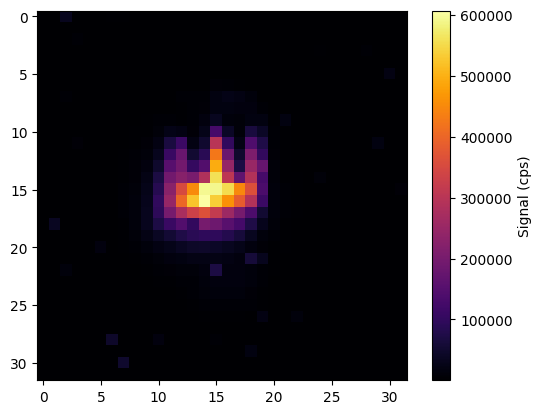

In [20]:
plt.imshow(sig_avg_cps[0], cmap='inferno')
plt.colorbar(label='Signal (cps)')


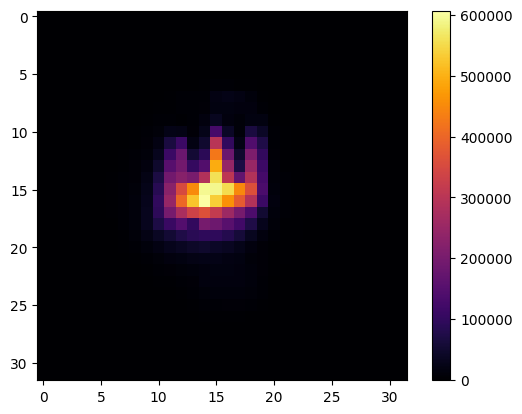

In [21]:
plt.imshow(sig_avg_cps_bgsub[0], cmap='inferno')
plt.colorbar()

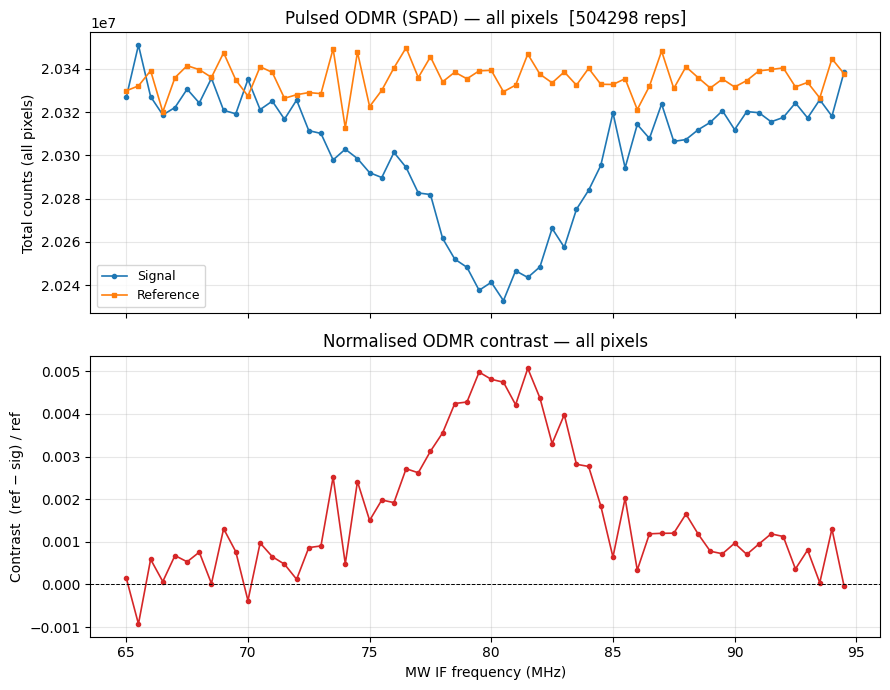

In [22]:
f_mhz = f_mw_hz / 1e6

# Sum all pixels at each frequency — identical to SPAD_ODMR_test
#sig_counts  = sig_avg.sum(axis=(-1, -2))   # (F,)
#ref_counts  = ref_avg.sum(axis=(-1, -2))   # (F,)

sig_counts  = sig_avg_cps_bgsub.sum(axis=(-1, -2))   # (F,)
ref_counts  = ref_avg_cps_bgsub.sum(axis=(-1, -2))   # (F,)

with np.errstate(divide='ignore', invalid='ignore'):
    contrast_all = np.where(ref_counts != 0, (ref_counts - sig_counts) / ref_counts, 0.0)

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

axes[0].plot(f_mhz, sig_counts, 'o-', ms=3, lw=1.2, label='Signal')
axes[0].plot(f_mhz, ref_counts, 's-', ms=3, lw=1.2, label='Reference')
axes[0].set_ylabel('Total counts (all pixels)')
axes[0].set_title(f'Pulsed ODMR (SPAD) — all pixels  [{n_complete_reps} reps]')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(f_mhz, contrast_all, 'o-', ms=3, lw=1.2, color='C3')
axes[1].axhline(0, color='k', lw=0.7, ls='--')
axes[1].set_xlabel('MW IF frequency (MHz)')
axes[1].set_ylabel('Contrast  (ref − sig) / ref')
axes[1].set_title('Normalised ODMR contrast — all pixels')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Array centre (brightest pixel in ref_avg.mean): row=16, col=14
  NV(0,0): pixel (14, 12)  OK
  NV(0,1): pixel (14, 14)  OK
  NV(0,2): pixel (14, 16)  OK
  NV(1,0): pixel (16, 12)  OK
  NV(1,1): pixel (16, 14)  OK
  NV(1,2): pixel (16, 16)  OK
  NV(2,0): pixel (18, 12)  OK
  NV(2,1): pixel (18, 14)  OK
  NV(2,2): pixel (18, 16)  OK


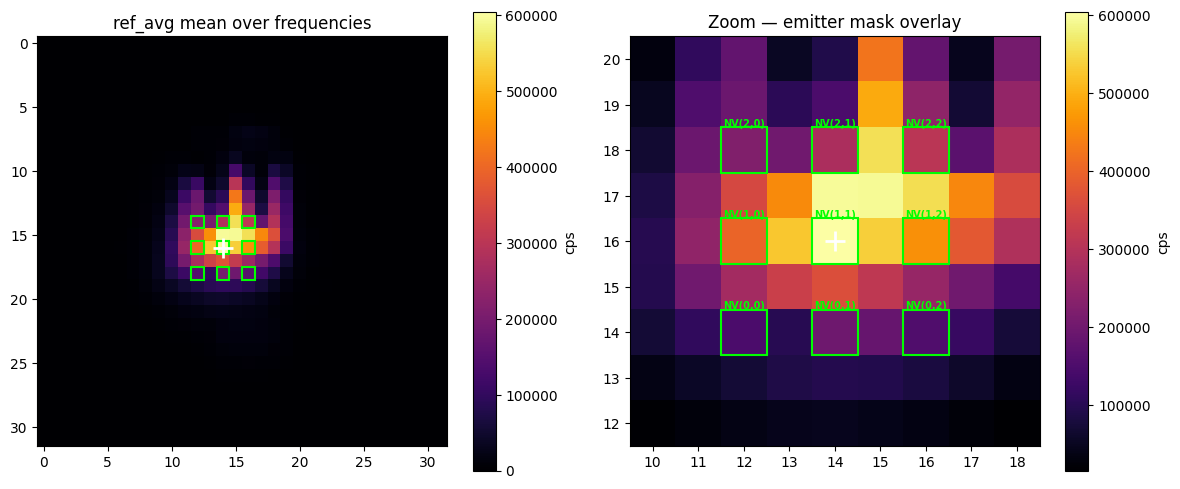

In [23]:
#FIXME: row order

# Use the mean reference frame (averaged over all frequencies) to find the array centre.
# ref_avg has no ODMR dip, so every frequency contributes equally — more robust than
# using a single signal frame that may be suppressed near resonance.
ref_frame = ref_avg_cps_bgsub.mean(axis=0)  # (rows, cols) — mean reference over all frequencies
bright_rc = np.unravel_index(ref_frame.argmax(), ref_frame.shape)
print(f'Array centre (brightest pixel in ref_avg.mean): row={bright_rc[0]}, col={bright_rc[1]}')

# 3×3 emitter mask: every other pixel → 5×5 footprint
# Offsets from centre pixel: -2, 0, +2 in both row and col
EMITTER_OFFSETS = [(-2, -2), (-2, 0), (-2, 2),
                   ( 0, -2), ( 0, 0), ( 0, 2),
                   ( 2, -2), ( 2, 0), ( 2, 2)]

# Label each emitter position in the 3×3 grid
EMITTER_LABELS = ['NV(0,0)', 'NV(0,1)', 'NV(0,2)',
                  'NV(1,0)', 'NV(1,1)', 'NV(1,2)',
                  'NV(2,0)', 'NV(2,1)', 'NV(2,2)']

# Compute absolute (row, col) for each emitter
emitter_pixels = [(bright_rc[0] + dr, bright_rc[1] + dc) for dr, dc in EMITTER_OFFSETS]

# Verify all pixels are inside the frame
for lbl, (r, c) in zip(EMITTER_LABELS, emitter_pixels):
    inside = 0 <= r < n_rows and 0 <= c < n_cols
    print(f'  {lbl}: pixel ({r:2d}, {c:2d})  {"OK" if inside else "OUT OF BOUNDS"}')

# Show the mask on the reference frame
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im0 = axes[0].imshow(ref_frame, cmap='inferno')
axes[0].set_title('ref_avg mean over frequencies')
fig.colorbar(im0, ax=axes[0], label='cps')

# Zoom view around the emitter array
pad = 4
r_lo = max(bright_rc[0] - pad, 0)
r_hi = min(bright_rc[0] + pad + 1, n_rows)
c_lo = max(bright_rc[1] - pad, 0)
c_hi = min(bright_rc[1] + pad + 1, n_cols)
im1 = axes[1].imshow(ref_frame[r_lo:r_hi, c_lo:c_hi], cmap='inferno',
                     extent=[c_lo - 0.5, c_hi - 0.5, r_lo - 0.5, r_hi - 0.5])
axes[1].set_title('Zoom — emitter mask overlay')
fig.colorbar(im1, ax=axes[1], label='cps')

# Overlay mask rectangles and labels
for ax in axes:
    for lbl, (r, c) in zip(EMITTER_LABELS, emitter_pixels):
        rect = plt.Rectangle((c - 0.5, r - 0.5), 1, 1,
                              linewidth=1.5, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)
    # Mark centre
    ax.plot(bright_rc[1], bright_rc[0], 'w+', ms=14, mew=2)

# Add text labels on zoom view
for lbl, (r, c) in zip(EMITTER_LABELS, emitter_pixels):
    axes[1].text(c, r + 0.7, lbl, ha='center', va='top', fontsize=7,
                 color='lime', fontweight='bold')


plt.tight_layout()
plt.show()

Array centre (brightest pixel in ref_avg.mean): row=16, col=14


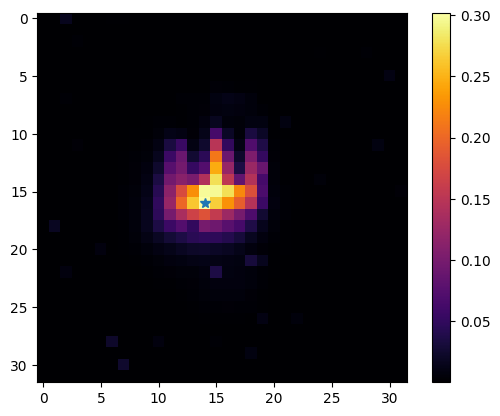

In [24]:
# Use the mean reference frame (averaged over all frequencies) to find the array centre.
# ref_avg has no ODMR dip, so every frequency contributes equally — more robust than
# using a single signal frame that may be suppressed near resonance.
ref_frame = ref_avg.mean(axis=0)  # (rows, cols) — mean reference over all frequencies
bright_rc = np.unravel_index(ref_frame.argmax(), ref_frame.shape)
print(f'Array centre (brightest pixel in ref_avg.mean): row={bright_rc[0]}, col={bright_rc[1]}')

plt.imshow(ref_frame, cmap='inferno')
plt.plot(bright_rc[1], bright_rc[0], '*', ms=7)
plt.colorbar()
plt.show()

bright_rc = (14,20)

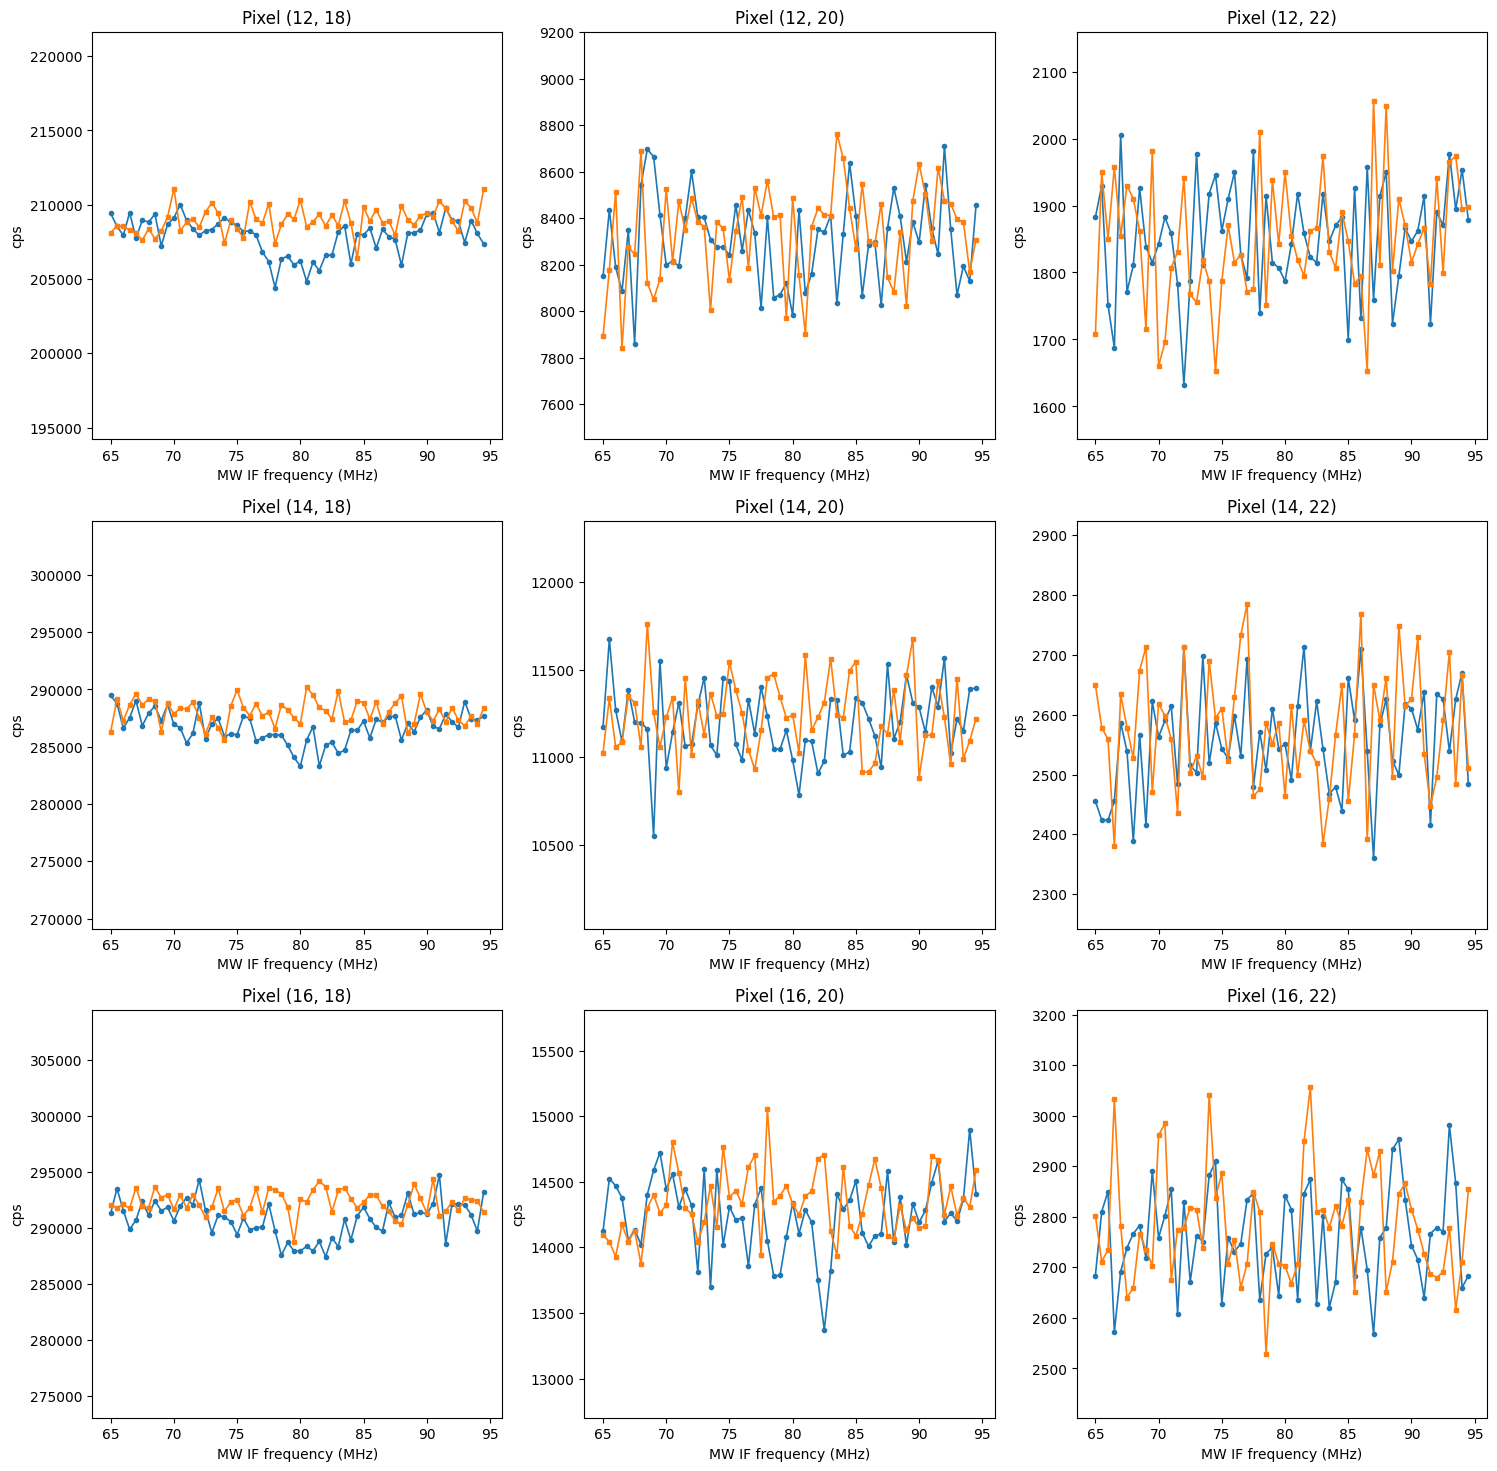

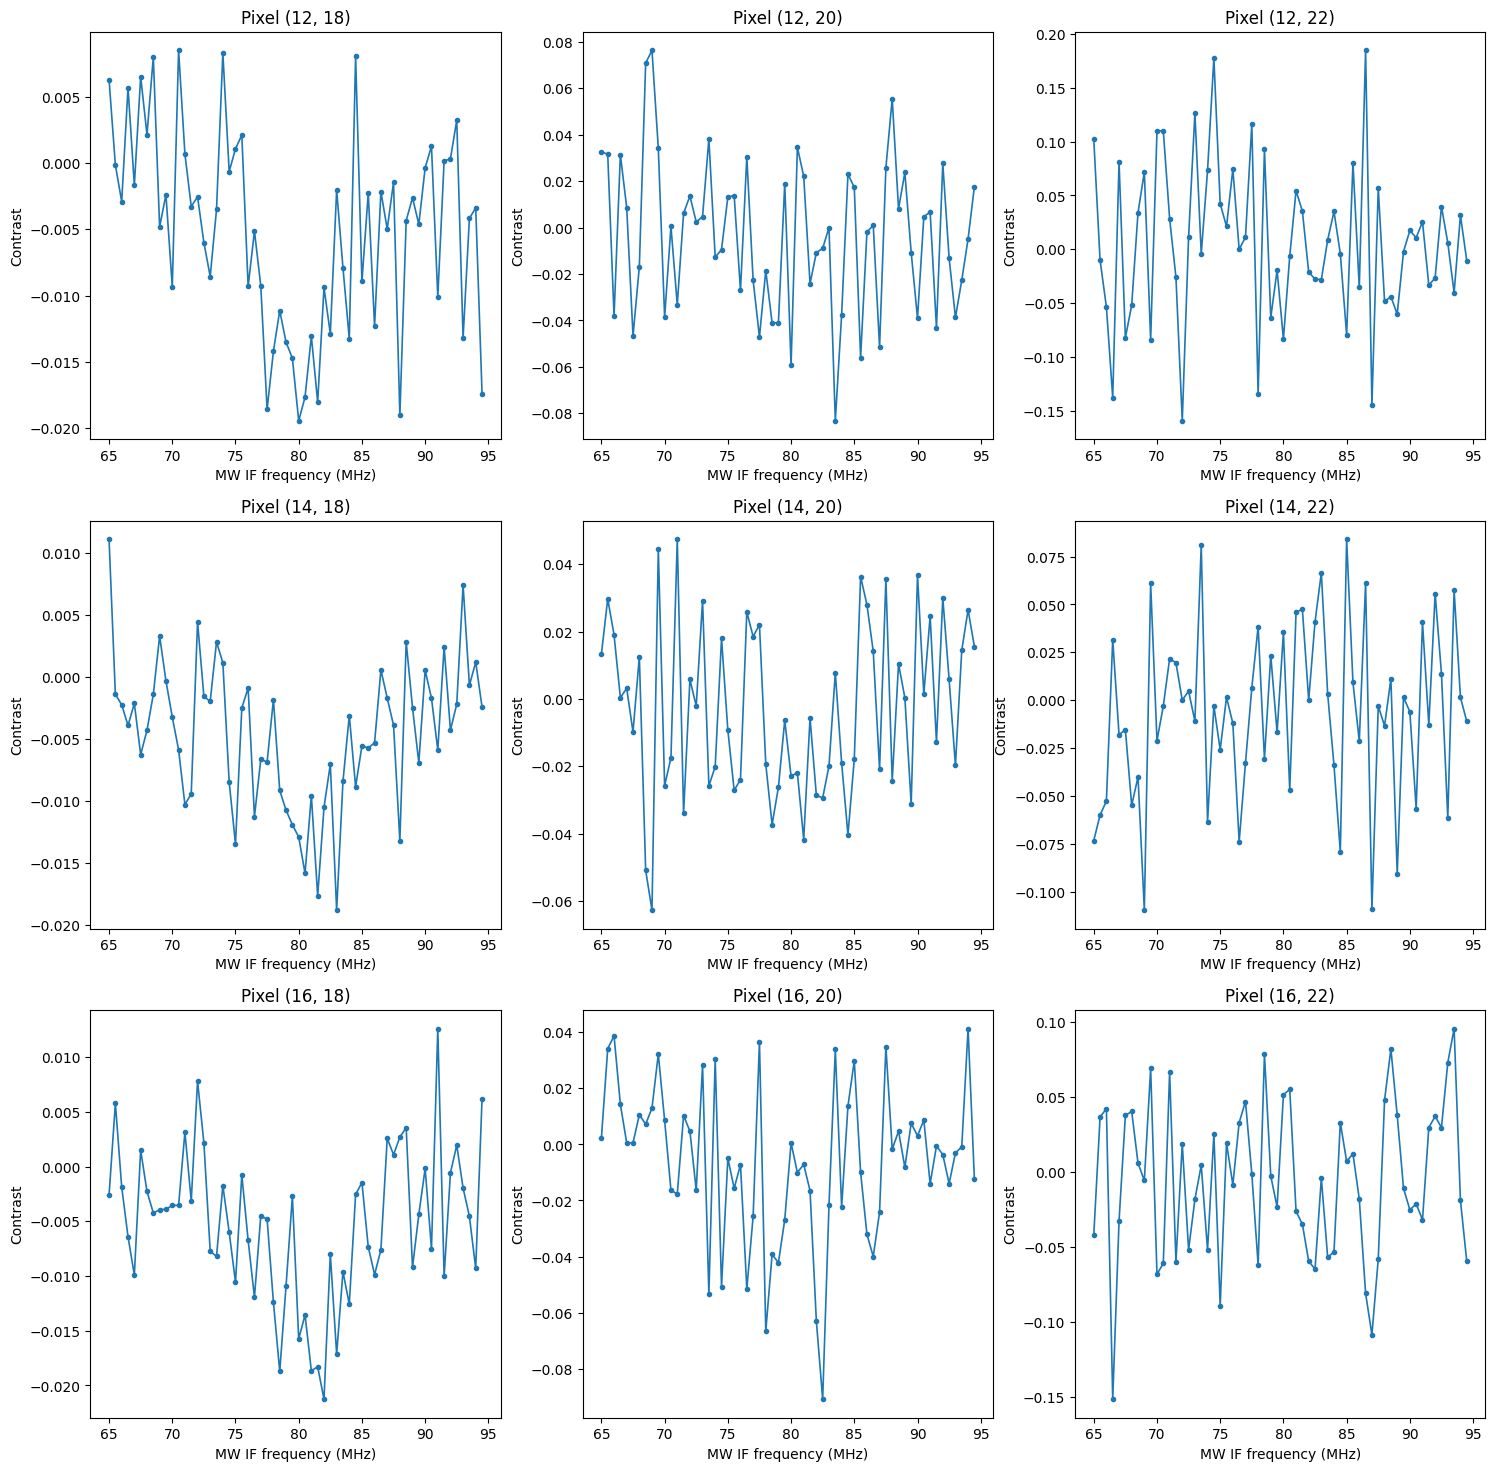

In [25]:
#make 3X3 grid of plots for the 9 emitter pixels
plt.subplots(3, 3, figsize=(18, 18))

for i in range(3):
    for j in range(3):
        sig = sig_avg_cps_bgsub[:, bright_rc[0]+2*i-2, bright_rc[1]+2*j-2]
        ref = ref_avg_cps_bgsub[:, bright_rc[0]+2*i-2, bright_rc[1]+2*j-2]

        plt.subplot(3, 3, i*3 + j + 1)
        plt.plot(f_mhz, sig, 'o-', ms=3, lw=1.2, label='Signal')
        plt.plot(f_mhz, ref, 's-', ms=3, lw=1.2, label='Reference')
        plt.ylim(min(sig.min(), ref.min()) * 0.95, max(sig.max(), ref.max()) * 1.05)
        plt.title(f'Pixel ({bright_rc[0]+2*i-2}, {bright_rc[1]+2*j-2})')
        plt.xlabel('MW IF frequency (MHz)')
        plt.ylabel('cps')

plt.subplots(3, 3, figsize=(18, 18))

for i in range(3):
    for j in range(3):
        sig = sig_avg_cps_bgsub[:, bright_rc[0]+2*i-2, bright_rc[1]+2*j-2]
        ref = ref_avg_cps_bgsub[:, bright_rc[0]+2*i-2, bright_rc[1]+2*j-2]
        plt.subplot(3, 3, i*3 + j + 1)

        plt.plot(f_mhz, (sig - ref)/ref , 'o-', ms=3, lw=1.2, label='Signal')
        plt.title(f'Pixel ({bright_rc[0]+2*i-2}, {bright_rc[1]+2*j-2})')
        plt.xlabel('MW IF frequency (MHz)')
        plt.ylabel('Contrast')
        

In [34]:
bright_rc

(14, 16)